# Combo: Disease Investigation

4-panel figure: healthy equilibrium → disease → symptoms → diagnosis.

In [1]:
import sys
from pathlib import Path

# Ensure alienbio is importable
_root = Path(".").resolve().parent.parent / "src"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
_demos = Path(".").resolve().parent
if str(_demos) not in sys.path:
    sys.path.insert(0, str(_demos))

%matplotlib inline


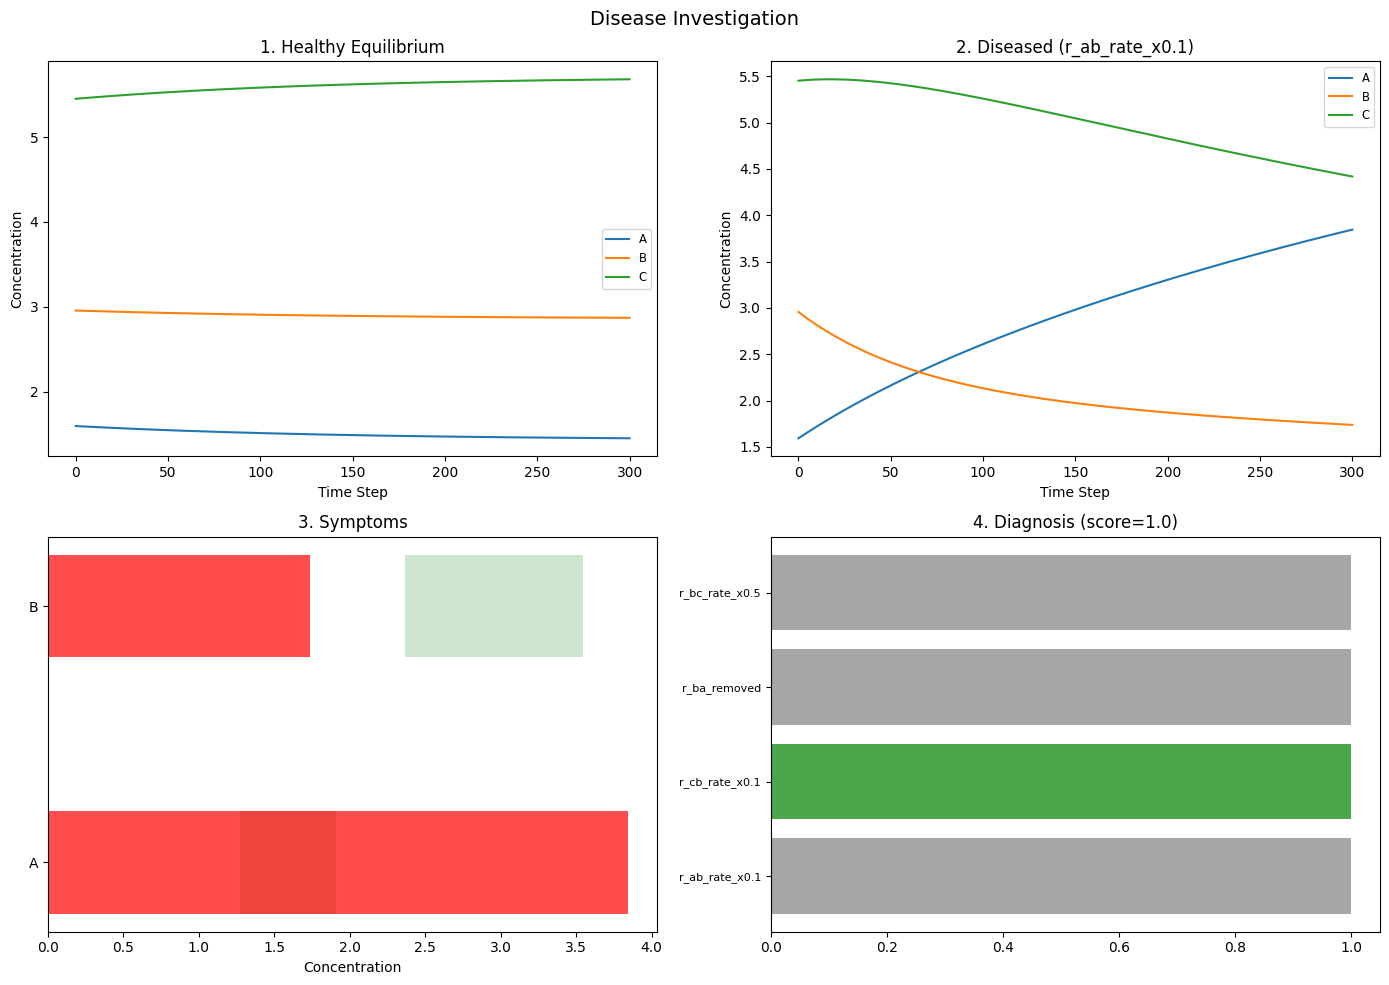

In [2]:
import matplotlib.pyplot as plt
from _shared import make_disease_system, oracle_agent
from alienbio.bio import (
    AgentInterface, BioSystem, detect_symptoms,
    generate_diagnosis_task, run_experiment,
)
from alienbio.viz import save_or_show

system, baseline, perturbations = make_disease_system(seed=42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Disease Investigation", fontsize=14)

# Panel 1: Healthy
healthy = BioSystem(system.chemistry, system.state.copy(), dt=0.1)
healthy_tl = healthy.run(300)
for mol in list(healthy_tl[0]):
    axes[0, 0].plot(range(len(healthy_tl)), [s[mol] for s in healthy_tl], label=mol)
axes[0, 0].set_title("1. Healthy Equilibrium")
axes[0, 0].set_xlabel("Time Step"); axes[0, 0].set_ylabel("Concentration"); axes[0, 0].legend(fontsize="small")

# Panel 2: Diseased
pert = perturbations[0]
diseased = BioSystem(system.chemistry, system.state.copy(), dt=0.1)
pert.apply(diseased)
diseased_tl = diseased.run(300)
for mol in list(diseased_tl[0]):
    axes[0, 1].plot(range(len(diseased_tl)), [s[mol] for s in diseased_tl], label=mol)
axes[0, 1].set_title(f"2. Diseased ({pert.name})")
axes[0, 1].set_xlabel("Time Step"); axes[0, 1].set_ylabel("Concentration"); axes[0, 1].legend(fontsize="small")

# Panel 3: Symptoms
concs = {m: diseased.state[m] for m in diseased.state}
symptoms = detect_symptoms(concs, baseline)
if symptoms:
    names = [s.molecule for s in symptoms]
    range_map = {r.molecule: r for r in baseline.ranges}
    for i, s in enumerate(symptoms):
        r = range_map.get(s.molecule)
        if r: axes[1, 0].barh(i, r.high - r.low, left=r.low, height=0.4, color="green", alpha=0.2)
    axes[1, 0].barh(range(len(names)), [s.value for s in symptoms], height=0.4, color="red", alpha=0.7)
    axes[1, 0].set_yticks(range(len(names))); axes[1, 0].set_yticklabels(names)
axes[1, 0].set_title("3. Symptoms"); axes[1, 0].set_xlabel("Concentration")

# Panel 4: Diagnosis
task = generate_diagnosis_task(system, perturbations, difficulty=2, seed=42)
interface = AgentInterface(BioSystem(system.chemistry, system.state.copy(), dt=0.1))
result = run_experiment(interface, task, oracle_agent)
cnames = [p.name for p in task.candidates]
colors = ["green" if i == task.correct_index else "gray" for i in range(len(cnames))]
axes[1, 1].barh(range(len(cnames)), [1]*len(cnames), color=colors, alpha=0.7)
axes[1, 1].set_yticks(range(len(cnames))); axes[1, 1].set_yticklabels(cnames, fontsize=8)
axes[1, 1].set_title(f"4. Diagnosis (score={result.score:.1f})")

fig.tight_layout()
plt.show()
